# GA Optimisation Analysis — LoadMatch CONUS

This notebook provides publication-ready figures for the genetic-algorithm
optimisation of the LoadMatch model.  Copy
`data/results_verification/factor_history.log` from the server before running.

In [1]:
import sys, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

repo_root = Path.cwd().resolve()
if not (repo_root / "scripts").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from scripts.factor_history_tools import (
    parse_factor_history,
    records_to_dataframe,
    FACTOR_COLUMNS,
    CAPACITY_COLUMNS,
)
from scripts.run_full_workflow import (
    PARAM_REGISTRY,
    FACTOR_KEYS,
    CAPACITY_FACTOR_KEYS,
    DEFAULT_LOCKED,
    parse_baseline_factors,
)

# ── Matplotlib defaults for publication ──
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "figure.constrained_layout.use": True,
})

SAVE_DIR = repo_root / "data/results_verification"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures will be saved to {SAVE_DIR}")

Figures will be saved to /Users/andreasmuhlbauer/Library/CloudStorage/OneDrive-Stanford/Research/JacobsonLab/2025LOADMATCH-PYTHON/loadmatch-python/data/results_verification


In [2]:
# ── Load data ──
LOG_PATH = repo_root / "data/results_verification/factor_history.log"
records = parse_factor_history(LOG_PATH)
df = records_to_dataframe(records)
print(f"Loaded {len(df)} trials from {LOG_PATH.name}")

# ── Parse generation / individual from label ──
def _parse_label(label):
    m = re.match(r"GA-gen(\d+)-ind(\d+)", label)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None

df["gen"], df["ind"] = zip(*df["label"].map(_parse_label))
ga_mask = df["gen"].notna()
df_ga = df[ga_mask].copy()
df_ga["gen"] = df_ga["gen"].astype(int)

n_gens = df_ga["gen"].max()
pop_size = df_ga.groupby("gen").size().median()
print(f"GA: {int(n_gens)} generations, population {int(pop_size)}")
print(f"Pre-GA trials (LP + inflate): {(~ga_mask).sum()}")

# ── Load baseline (previous publication) ──
BASELINE_PATH = repo_root / "data/raw/baseline_results.dat"
baseline_factors = parse_baseline_factors(BASELINE_PATH)
print(f"\nBaseline factors loaded: {len(baseline_factors)} parameters")

Loaded 1813 trials from factor_history.log
GA: 50 generations, population 36
Pre-GA trials (LP + inflate): 13

Baseline factors loaded: 25 parameters


In [3]:
# ── Per-generation aggregates ──
# Best feasible cost in each generation (cumulative best)
gen_best = []
cum_best = float("inf")
for g in range(1, int(n_gens) + 1):
    gen_df = df_ga[df_ga["gen"] == g]
    feasible = gen_df[gen_df["feasible"] == True]
    if len(feasible):
        gen_min = feasible["cost_mn_bil_per_year"].min()
        cum_best = min(cum_best, gen_min)
    gen_best.append({
        "gen": g,
        "gen_best_cost": feasible["cost_mn_bil_per_year"].min() if len(feasible) else float("inf"),
        "cum_best_cost": cum_best,
        "n_feasible": len(feasible),
        "n_total": len(gen_df),
        "feas_frac": len(feasible) / len(gen_df) if len(gen_df) else 0,
    })
df_gen = pd.DataFrame(gen_best)

# Best individual overall
best_row = df[(df["feasible"] == True) & (df["cost_mn_bil_per_year"] < float("inf"))]
best_row = best_row.loc[best_row["cost_mn_bil_per_year"].idxmin()]
print(f"Best feasible: trial {best_row['trial']} ({best_row['label']}), "
      f"cost ${best_row['cost_mn_bil_per_year']:.2f}B/yr")

Best feasible: trial 1805 (GA-gen50-ind29), cost $715.23B/yr


## Figure 1 — Cost convergence and feasibility rate

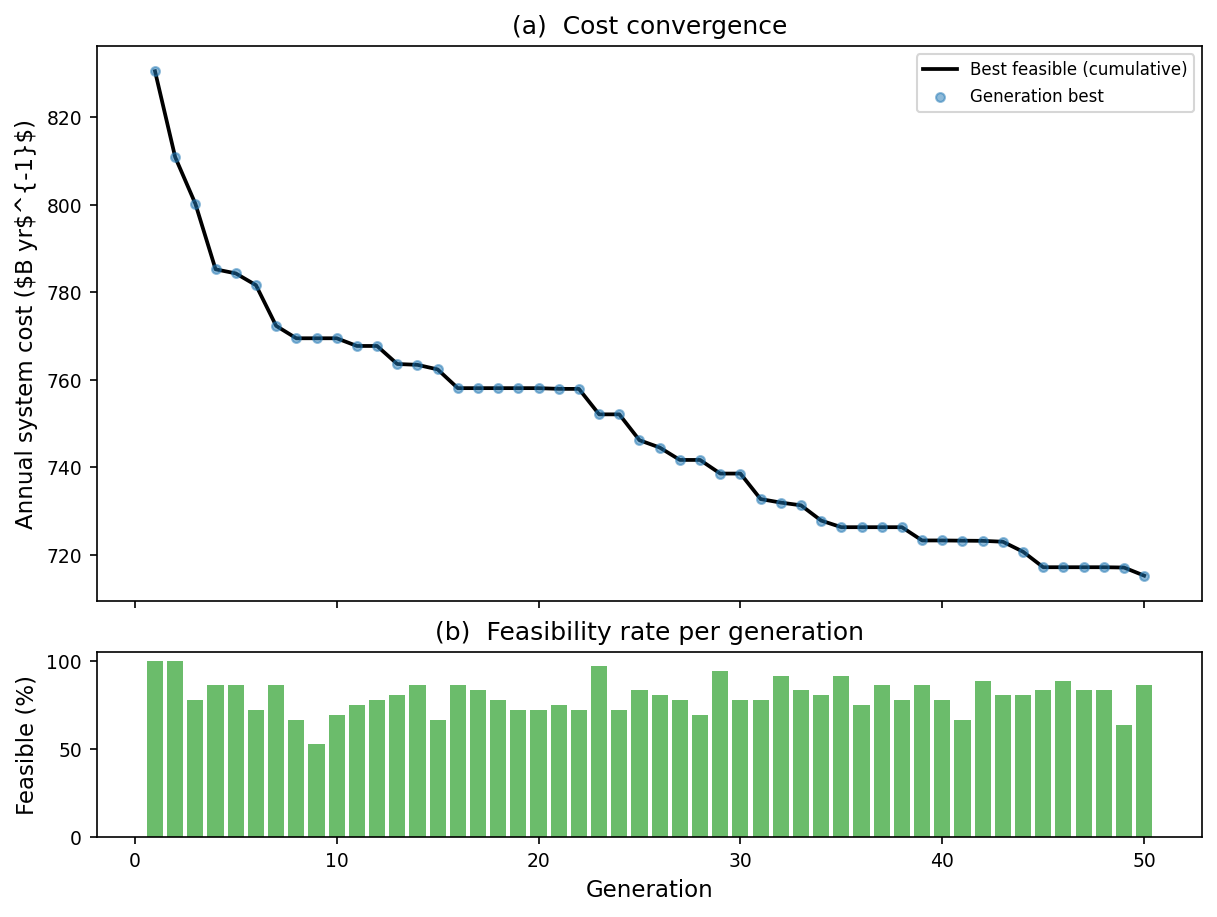

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

# ── Top: cost trajectory ──
ax = axes[0]
valid = df_gen[df_gen["cum_best_cost"] < float("inf")]
ax.plot(valid["gen"], valid["cum_best_cost"], "k-", lw=1.8, label="Best feasible (cumulative)")
# Per-gen best as lighter scatter
gen_valid = df_gen[df_gen["gen_best_cost"] < float("inf")]
ax.scatter(gen_valid["gen"], gen_valid["gen_best_cost"],
           s=18, c="tab:blue", alpha=0.5, zorder=3, label="Generation best")
ax.set_ylabel("Annual system cost ($B yr$^{-1}$)")
ax.legend(loc="upper right")
ax.set_title("(a)  Cost convergence")

# ── Bottom: feasibility fraction ──
ax2 = axes[1]
ax2.bar(df_gen["gen"], df_gen["feas_frac"] * 100, color="tab:green", alpha=0.7, width=0.8)
ax2.set_ylabel("Feasible (%)")
ax2.set_xlabel("Generation")
ax2.set_ylim(0, 105)
ax2.set_title("(b)  Feasibility rate per generation")

fig.savefig(SAVE_DIR / "fig1_cost_convergence.pdf", bbox_inches="tight")
plt.show()

## Figure 2 — Capacity-factor trajectories (best-per-generation)

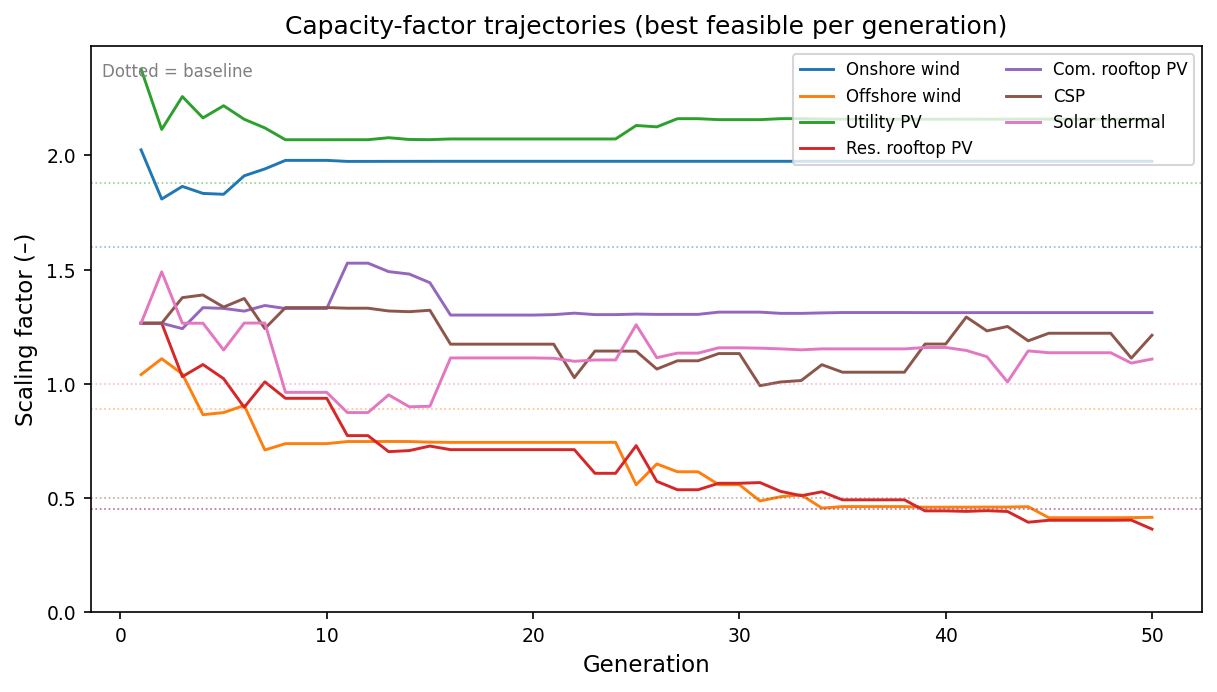

In [6]:
# Extract the best feasible individual per generation
best_per_gen = []
for g in range(1, int(n_gens) + 1):
    gen_df = df_ga[(df_ga["gen"] == g) & (df_ga["feasible"] == True)]
    if len(gen_df):
        best_per_gen.append(gen_df.loc[gen_df["cost_mn_bil_per_year"].idxmin()])
df_best = pd.DataFrame(best_per_gen)

CAP_LABELS = {
    "faconwin":   "Onshore wind",
    "facoffwin":  "Offshore wind",
    "facutilpv":  "Utility PV",
    "facrespv":   "Res. rooftop PV",
    "faccompv":   "Com. rooftop PV",
    "cspturbfac": "CSP",
    "facsht":     "Solar thermal",
}

fig, ax = plt.subplots(figsize=(8, 4.5))
for col, label in CAP_LABELS.items():
    ax.plot(df_best["gen"], df_best[col], lw=1.4, label=label)
    # Baseline marker
    bval = baseline_factors.get(col.upper())
    if bval is not None:
        ax.axhline(bval, color=ax.get_lines()[-1].get_color(), ls=":", lw=0.8, alpha=0.5)

ax.set_xlabel("Generation")
ax.set_ylabel("Scaling factor (–)")
ax.legend(loc="upper right", ncol=2)
ax.set_title("Capacity-factor trajectories (best feasible per generation)")
ax.set_ylim(bottom=0)
# Dotted lines = baseline annotation
ax.annotate("Dotted = baseline", xy=(0.01, 0.97), xycoords="axes fraction",
            fontsize=8, va="top", color="gray")

fig.savefig(SAVE_DIR / "fig2_capacity_factors.pdf", bbox_inches="tight")
plt.show()

## Figure 3 — Non-capacity parameter trajectories (6-panel)

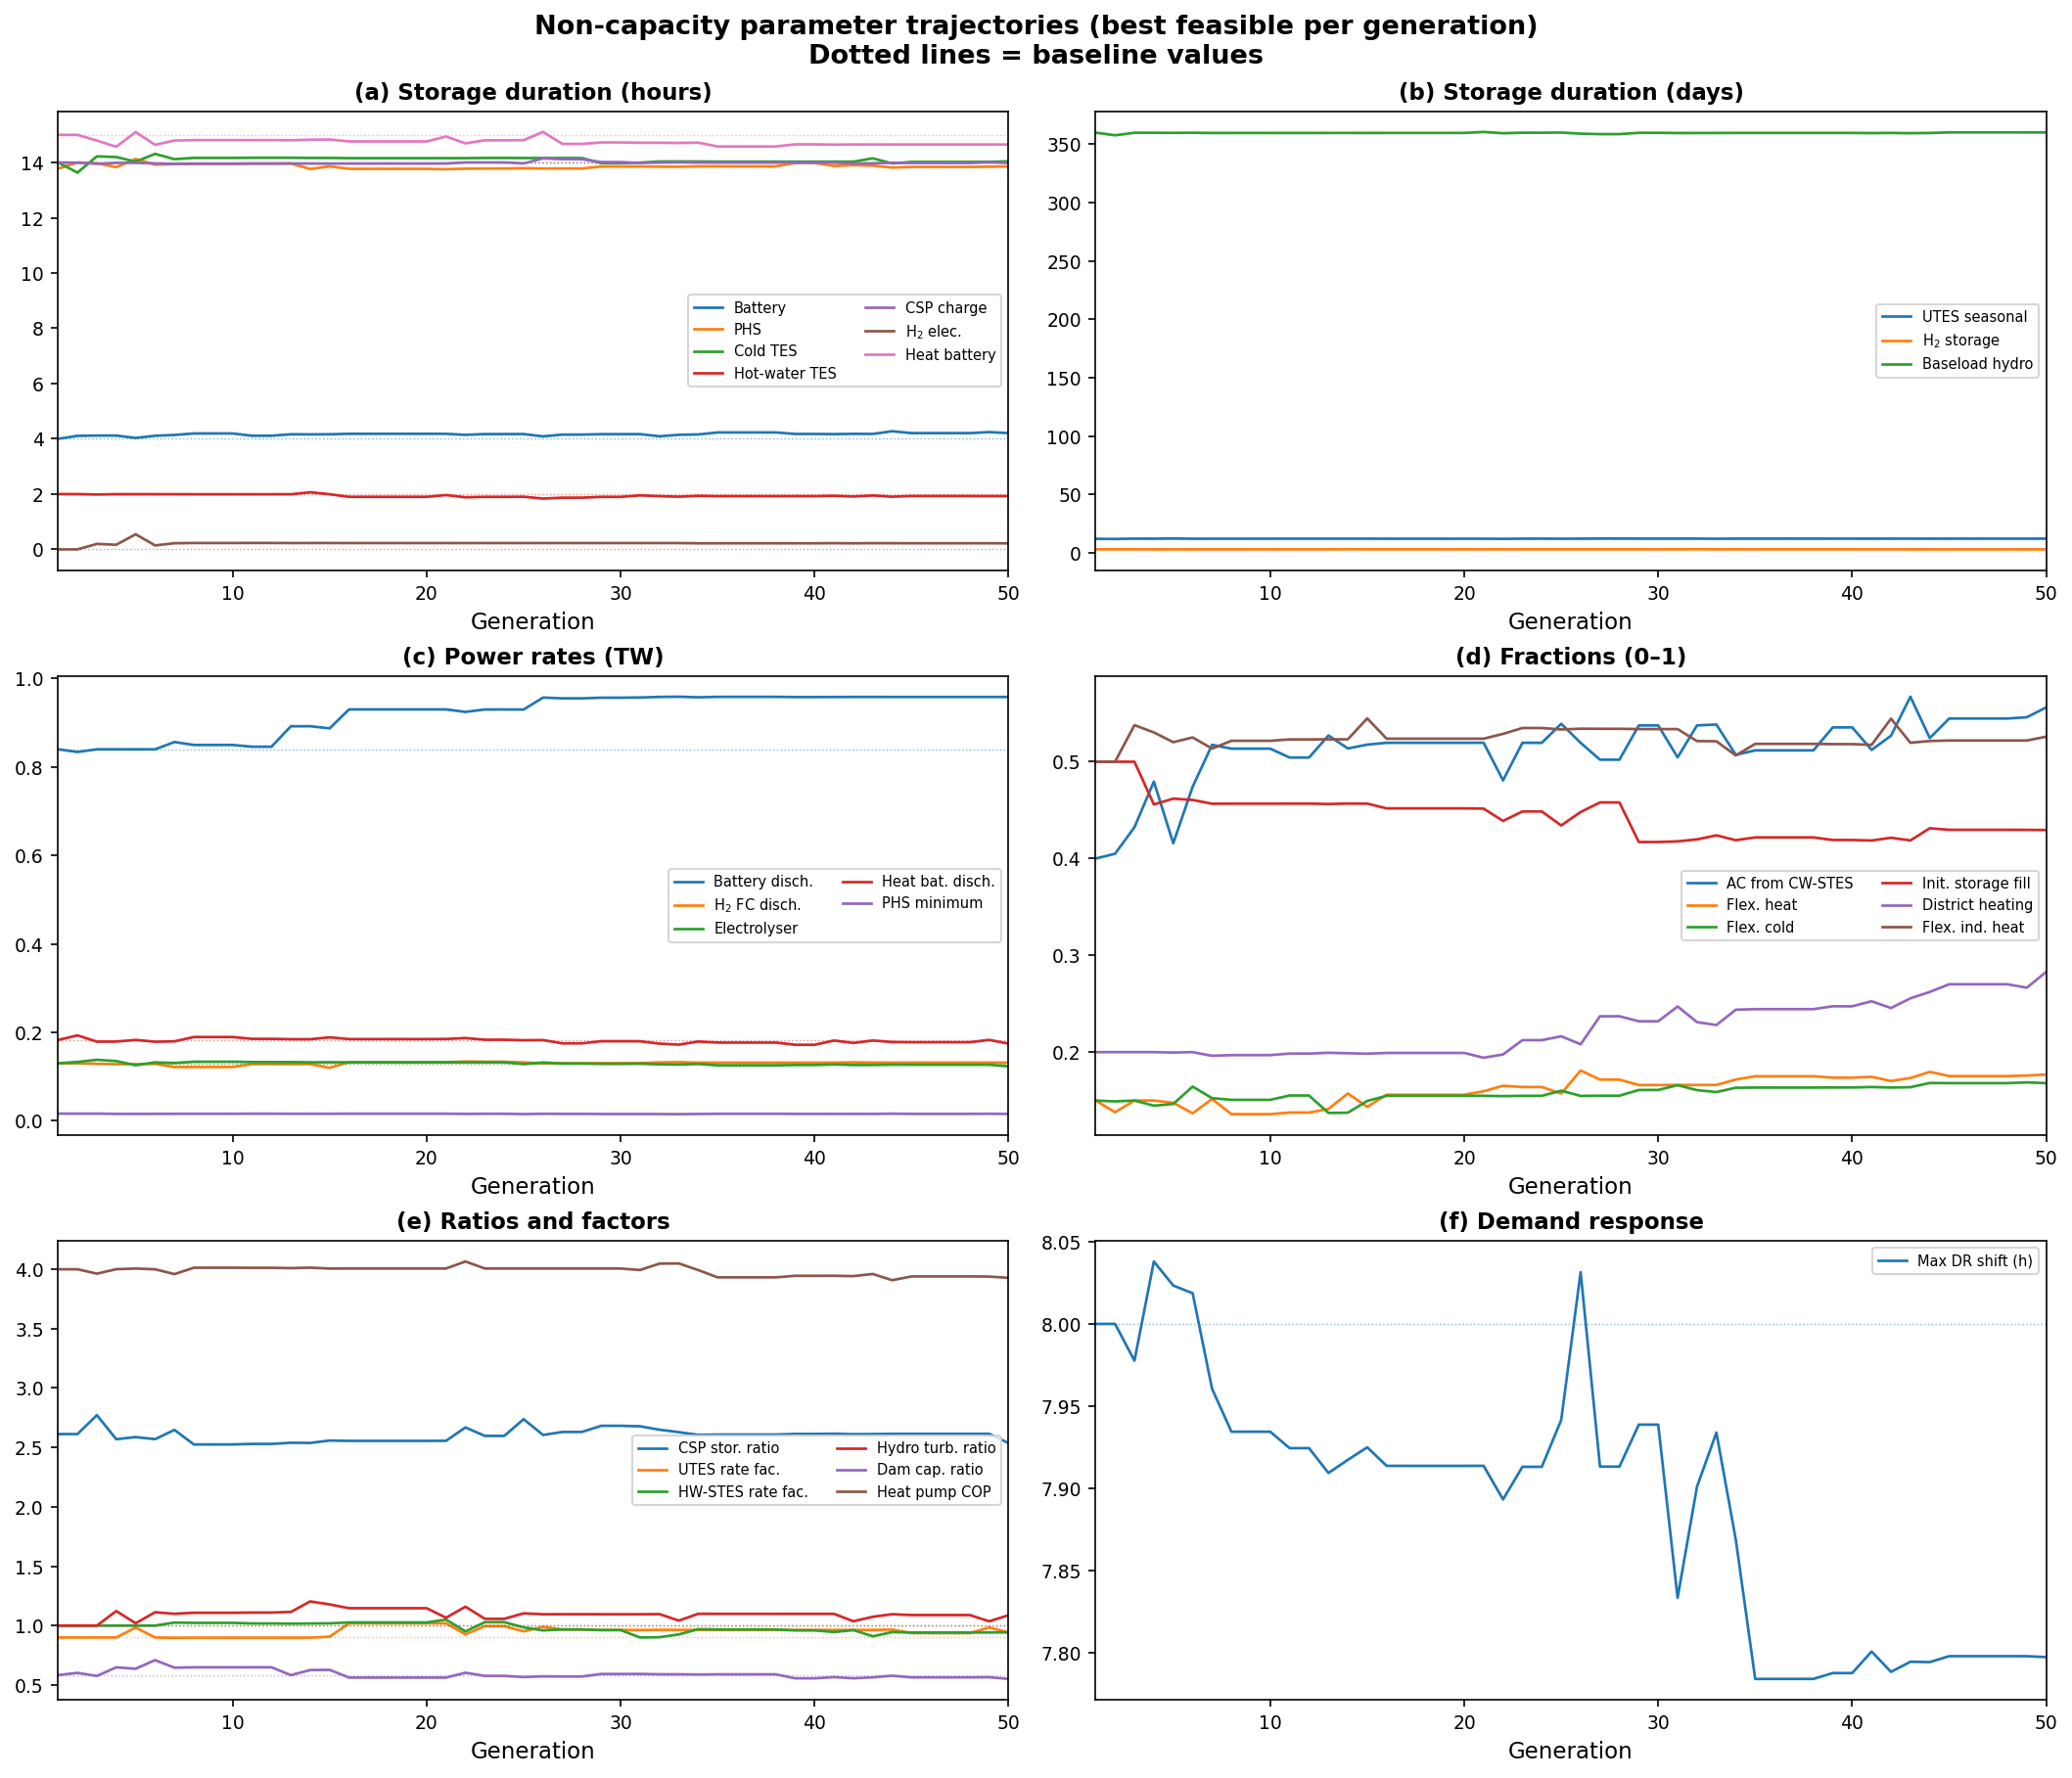

In [7]:
# Group non-capacity parameters by physical category for plotting
PANEL_GROUPS = {
    "(a) Storage duration (hours)": {
        "storhbat":   "Battery",
        "storhphs":   "PHS",
        "storhcold":  "Cold TES",
        "storhhwat":  "Hot-water TES",
        "hcharcsp":   "CSP charge",
        "storhhfc":   "H$_2$ elec.",
        "storhhbt":   "Heat battery",
    },
    "(b) Storage duration (days)": {
        "storugdys":  "UTES seasonal",
        "dayh2stor":  "H$_2$ storage",
        "daybashyd":  "Baseload hydro",
    },
    "(c) Power rates (TW)": {
        "batdisch":   "Battery disch.",
        "fcdisch":    "H$_2$ FC disch.",
        "fccharg":    "Electrolyser",
        "hbtdisch":   "Heat bat. disch.",
        "phsmin":     "PHS minimum",
    },
    "(d) Fractions (0–1)": {
        "coolstes":   "AC from CW-STES",
        "fheatflx":   "Flex. heat",
        "fcoldflx":   "Flex. cold",
        "frstorinit": "Init. storage fill",
        "fdistheat":  "District heating",
        "frcihflex":  "Flex. ind. heat",
    },
    "(e) Ratios and factors": {
        "cspstorgat":  "CSP stor. ratio",
        "ugfac":       "UTES rate fac.",
        "hwfac":       "HW-STES rate fac.",
        "hpturbrat":   "Hydro turb. ratio",
        "damcaprat":   "Dam cap. ratio",
        "cperform":    "Heat pump COP",
    },
    "(f) Demand response": {
        "mxhrdrm":    "Max DR shift (h)",
    },
}

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes_flat = axes.flatten()

for ax, (panel_title, param_dict) in zip(axes_flat, PANEL_GROUPS.items()):
    for col, label in param_dict.items():
        if col in df_best.columns:
            ax.plot(df_best["gen"], df_best[col], lw=1.3, label=label)
            # Baseline reference
            bval = baseline_factors.get(col.upper())
            if bval is not None:
                ax.axhline(bval, color=ax.get_lines()[-1].get_color(),
                           ls=":", lw=0.7, alpha=0.5)
    ax.set_title(panel_title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Generation")
    ax.legend(loc="best", fontsize=7, ncol=2 if len(param_dict) > 3 else 1)
    ax.set_xlim(1, n_gens)

fig.suptitle("Non-capacity parameter trajectories (best feasible per generation)\n"
             "Dotted lines = baseline values", fontsize=13, fontweight="bold")
fig.savefig(SAVE_DIR / "fig3_parameter_trajectories.pdf", bbox_inches="tight")
plt.show()

## Figure 4 — Baseline vs GA-optimised: final parameter comparison

In [8]:
# Build comparison table: baseline value, GA-optimal value, default, for every parameter
rows = []
for key in FACTOR_KEYS:
    default_val = PARAM_REGISTRY[key][0]
    category = PARAM_REGISTRY[key][1]
    desc = PARAM_REGISTRY[key][2]
    col = key.lower()
    ga_val = best_row[col] if col in best_row.index else default_val
    bl_val = baseline_factors.get(key, default_val)
    locked = key in DEFAULT_LOCKED
    rows.append({
        "Parameter": key,
        "Category": category,
        "Default": default_val,
        "Baseline": bl_val,
        "GA optimal": ga_val,
        "Change vs baseline (%)": 100 * (ga_val - bl_val) / max(abs(bl_val), 1e-12),
        "Locked": locked,
        "Description": desc,
    })
df_compare = pd.DataFrame(rows)

# Print a formatted table
print(f"{'Parameter':>12s}  {'Category':>9s}  {'Default':>9s}  {'Baseline':>9s}  "
      f"{'GA opt.':>9s}  {'Δ%':>7s}  Description")
print("─" * 100)
for _, r in df_compare.iterrows():
    lock_marker = " 🔒" if r["Locked"] else ""
    pct = f"{r['Change vs baseline (%)']:+.1f}%" if not r["Locked"] else "locked"
    print(f"{r['Parameter']:>12s}  {r['Category']:>9s}  {r['Default']:9.4f}  "
          f"{r['Baseline']:9.4f}  {r['GA optimal']:9.4f}  {pct:>7s}  {r['Description']}{lock_marker}")

   Parameter   Category    Default   Baseline    GA opt.       Δ%  Description
────────────────────────────────────────────────────────────────────────────────────────────────────
    FACONWIN   capacity     1.0000     1.6000     1.9740   +23.4%  Onshore wind capacity scaling
   FACOFFWIN   capacity     1.0000     0.8900     0.4149   -53.4%  Offshore wind capacity scaling
   FACUTILPV   capacity     1.0000     1.8800     2.1586   +14.8%  Utility-scale PV capacity scaling
    FACRESPV   capacity     1.0000     0.4500     0.3634   -19.2%  Residential rooftop PV scaling
    FACCOMPV   capacity     1.0000     0.4500     1.3114  +191.4%  Commercial rooftop PV scaling
  CSPTURBFAC   capacity     1.0000     0.5000     1.2123  +142.5%  CSP turbine capacity ratio
      FACSHT   capacity     1.0000     1.0000     1.1080   +10.8%  Solar thermal heat scaling
  CSPSTORGAT      ratio     2.6124     2.6124     2.5359    -2.9%  CSP storage charge/discharge ratio
     MXHRDRM      hours    11.0000     

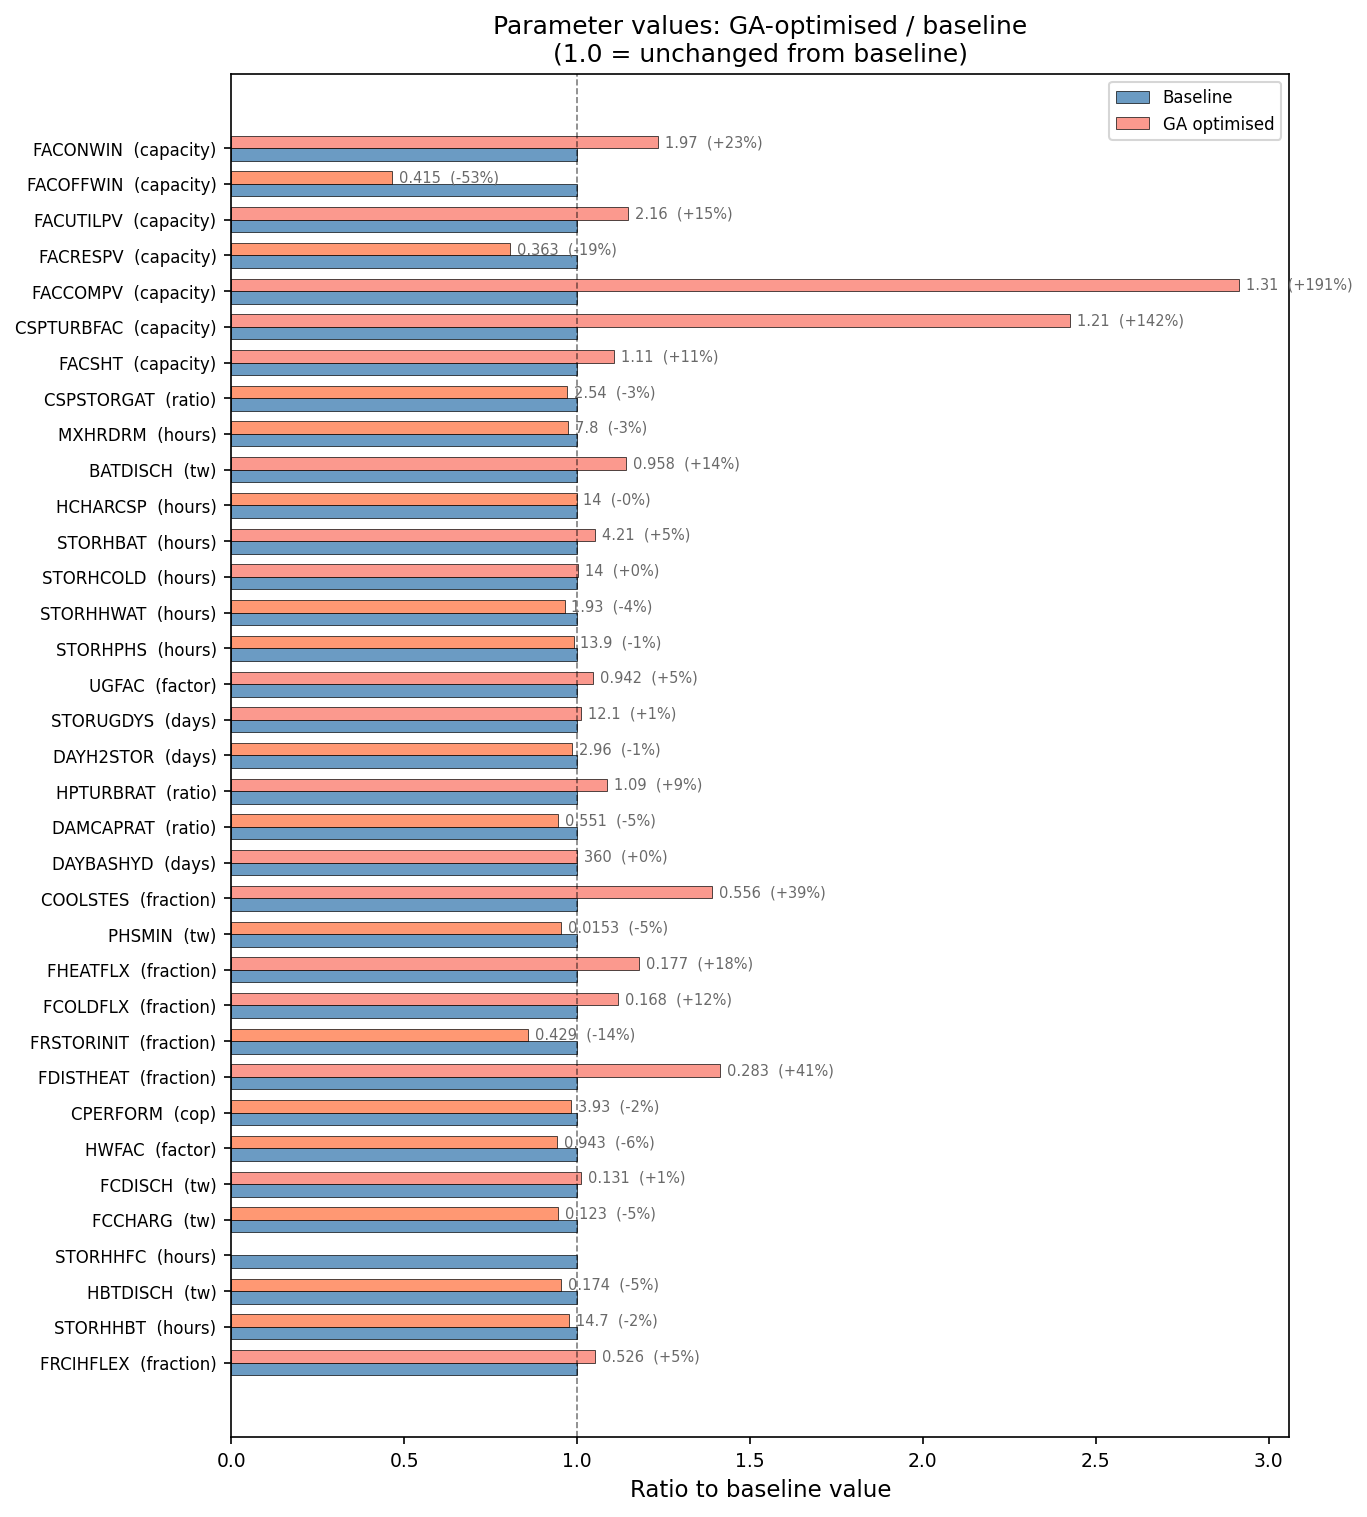

In [9]:
# Horizontal bar chart: baseline vs GA for all active (non-locked) parameters
# Normalise each parameter by its baseline value so bars are comparable
active = df_compare[~df_compare["Locked"]].copy()
active["bl_norm"] = 1.0  # baseline = 1.0 by definition
active["ga_norm"] = active["GA optimal"] / active["Baseline"].replace(0, np.nan)
# For parameters where baseline is 0 (e.g. STORHHFC), show absolute value instead
zero_bl = active["Baseline"].abs() < 1e-12
active.loc[zero_bl, "ga_norm"] = np.nan  # handle separately

fig, ax = plt.subplots(figsize=(9, 10))
y = np.arange(len(active))
h = 0.35

# Baseline bars (all = 1.0 by definition)
ax.barh(y + h/2, active["bl_norm"], h, color="steelblue", edgecolor="black",
        lw=0.4, label="Baseline", alpha=0.8)
# GA bars (ratio to baseline)
ga_vals = active["ga_norm"].values
colours = ["coral" if v <= 1.0 else "salmon" for v in ga_vals]
ax.barh(y - h/2, ga_vals, h, color=colours, edgecolor="black",
        lw=0.4, label="GA optimised", alpha=0.8)

ax.axvline(1.0, color="black", ls="--", lw=0.8, alpha=0.5)
ax.set_yticks(y)
ax.set_yticklabels([f"{r['Parameter']}  ({r['Category']})" for _, r in active.iterrows()],
                   fontsize=8)
ax.set_xlabel("Ratio to baseline value")
ax.set_title("Parameter values: GA-optimised / baseline\n(1.0 = unchanged from baseline)")
ax.legend(loc="upper right")
ax.invert_yaxis()

# Annotate actual values on the right
for i, (_, r) in enumerate(active.iterrows()):
    bl_str = f"{r['Baseline']:.3g}"
    ga_str = f"{r['GA optimal']:.3g}"
    pct = r["Change vs baseline (%)"]
    ax.annotate(f"{ga_str}  ({pct:+.0f}%)", xy=(max(ga_vals[i] or 0, 0) + 0.02, i - h/2),
                fontsize=7, va="center", color="dimgray")

fig.savefig(SAVE_DIR / "fig4_baseline_vs_ga.pdf", bbox_inches="tight")
plt.show()

## Figure 5 — Population cost distribution per generation

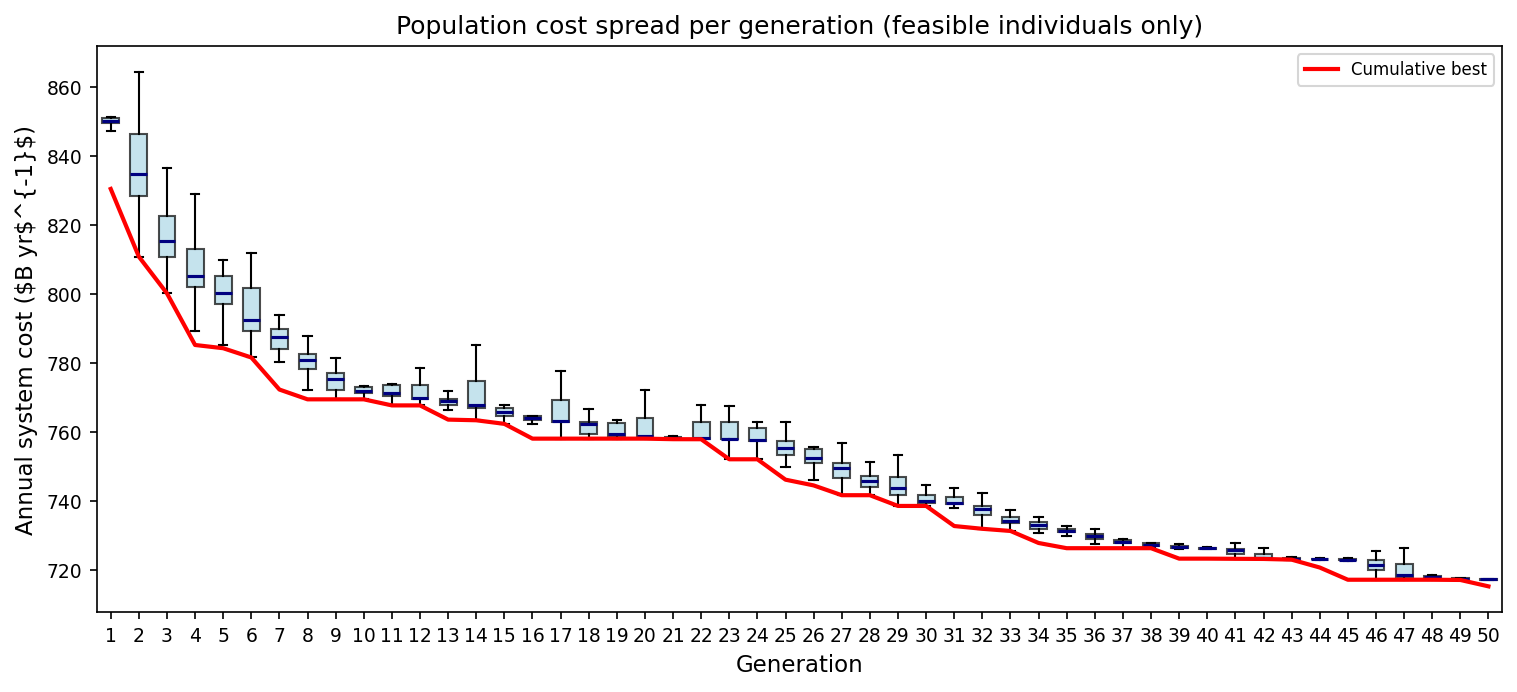

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.5))

# Box-plot of feasible costs per generation
gen_costs = []
gen_positions = []
for g in range(1, int(n_gens) + 1):
    feas = df_ga[(df_ga["gen"] == g) & (df_ga["feasible"] == True)]["cost_mn_bil_per_year"]
    feas = feas[feas < float("inf")]
    if len(feas) >= 2:
        gen_costs.append(feas.values)
        gen_positions.append(g)

bp = ax.boxplot(gen_costs, positions=gen_positions, widths=0.6,
                patch_artist=True, showfliers=False,
                boxprops=dict(facecolor="lightblue", alpha=0.7),
                medianprops=dict(color="navy", lw=1.5))

# Overlay cumulative best
valid = df_gen[df_gen["cum_best_cost"] < float("inf")]
ax.plot(valid["gen"], valid["cum_best_cost"], "r-", lw=2, label="Cumulative best", zorder=5)

ax.set_xlabel("Generation")
ax.set_ylabel("Annual system cost ($B yr$^{-1}$)")
ax.set_title("Population cost spread per generation (feasible individuals only)")
ax.legend(loc="upper right")
ax.set_xlim(0.5, n_gens + 0.5)

fig.savefig(SAVE_DIR / "fig5_cost_distribution.pdf", bbox_inches="tight")
plt.show()

## Figure 6 — Parameter sensitivity: coefficient of variation across feasible GA population

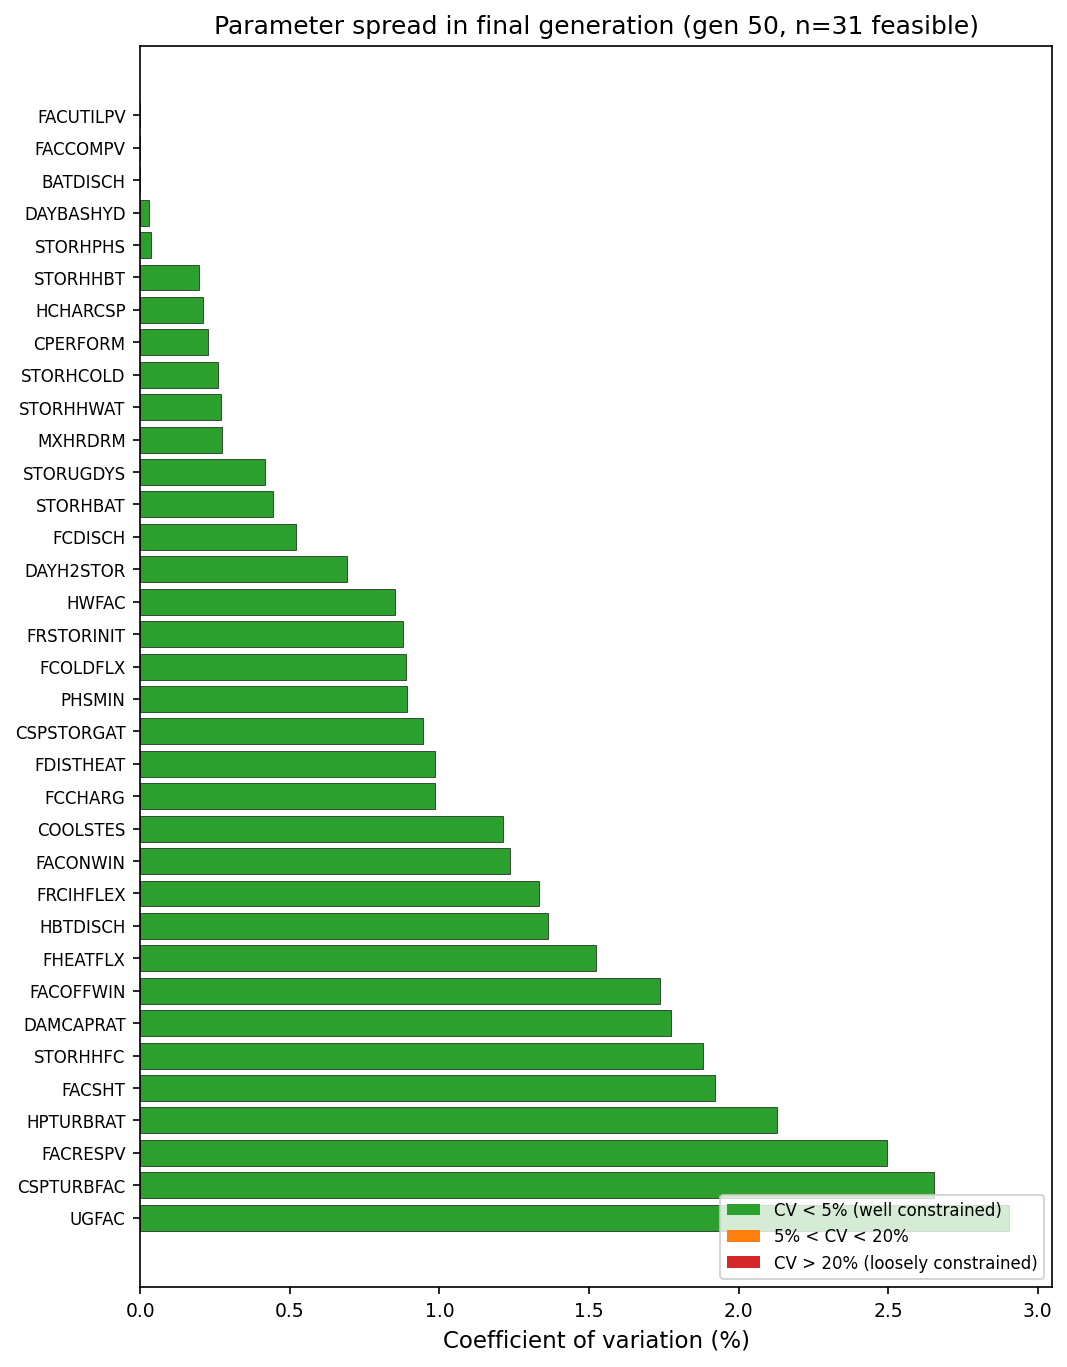

In [11]:
# Coefficient of variation across the final generation's feasible population
# Higher CV = parameter is less well-constrained by the objective
last_gen = df_ga[(df_ga["gen"] == int(n_gens)) & (df_ga["feasible"] == True)]
cols = [c for c in FACTOR_COLUMNS if c in last_gen.columns and c.upper() not in DEFAULT_LOCKED]

cv_data = []
for col in cols:
    vals = last_gen[col].dropna()
    mean_ = vals.mean()
    std_ = vals.std()
    cv = std_ / abs(mean_) * 100 if abs(mean_) > 1e-12 else 0.0
    cv_data.append({"Parameter": col.upper(), "CV (%)": cv, "Mean": mean_, "Std": std_})
df_cv = pd.DataFrame(cv_data).sort_values("CV (%)", ascending=True)

fig, ax = plt.subplots(figsize=(7, 9))
colors = ["tab:red" if cv > 20 else "tab:orange" if cv > 5 else "tab:green"
          for cv in df_cv["CV (%)"].values]
ax.barh(range(len(df_cv)), df_cv["CV (%)"].values, color=colors, edgecolor="black", lw=0.3)
ax.set_yticks(range(len(df_cv)))
ax.set_yticklabels(df_cv["Parameter"].values, fontsize=8)
ax.set_xlabel("Coefficient of variation (%)")
ax.set_title(f"Parameter spread in final generation (gen {int(n_gens)}, "
             f"n={len(last_gen)} feasible)")
ax.invert_yaxis()

# Legend for colour coding
legend_elements = [
    Patch(facecolor="tab:green", label="CV < 5% (well constrained)"),
    Patch(facecolor="tab:orange", label="5% < CV < 20%"),
    Patch(facecolor="tab:red", label="CV > 20% (loosely constrained)"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=8)

fig.savefig(SAVE_DIR / "fig6_parameter_sensitivity.pdf", bbox_inches="tight")
plt.show()

## Figure 7 — Capacity evolution bar chart (LP → inflate → GA optimal)

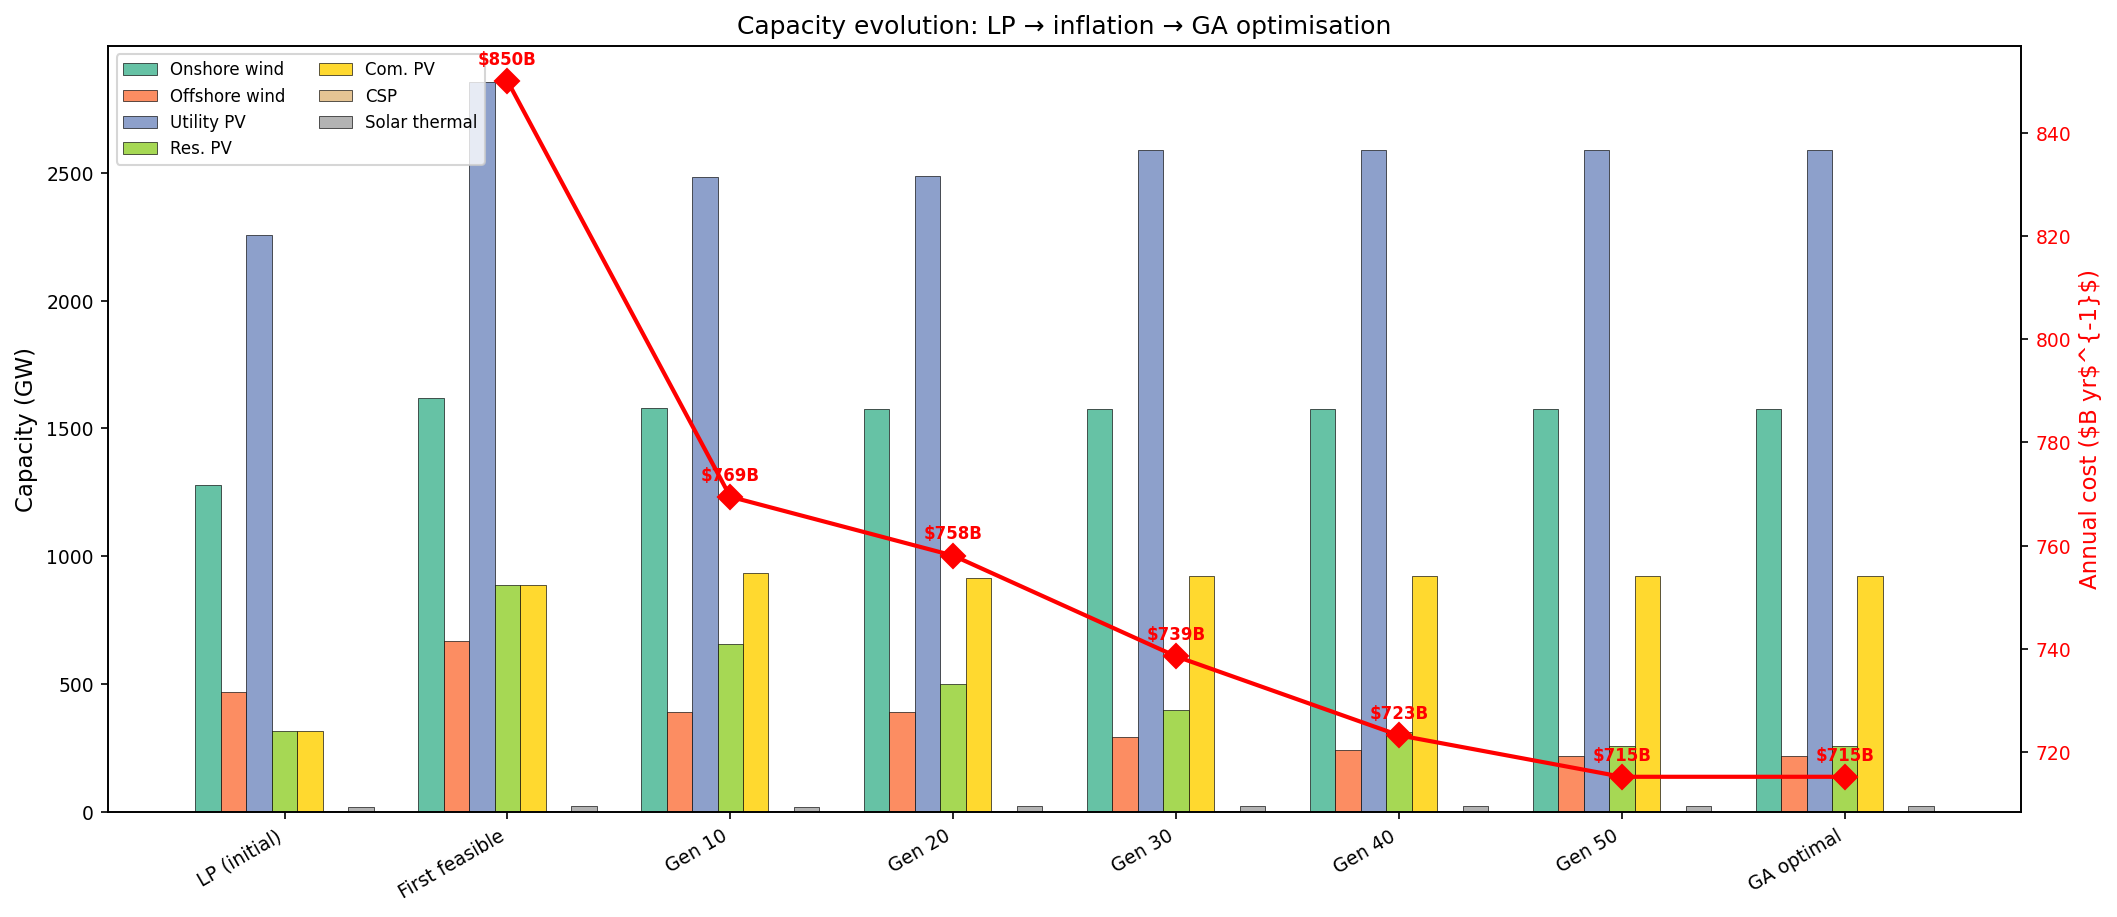

In [12]:
# Base capacities for USA from countrystats.dat (in MW)
BASE_CAPACITIES_USA = {
    "onshore_wind": 798934.02,
    "offshore_wind": 526241.51,
    "utility_pv": 1199905.98,
    "res_rooftop_pv": 701942.21,
    "com_rooftop_pv": 701942.21,
    "csp": 1119.82,
    "solar_thermal": 18185.00,
}

FACTOR_TO_BASE = {
    "faconwin": ("onshore_wind", "Onshore wind"),
    "facoffwin": ("offshore_wind", "Offshore wind"),
    "facutilpv": ("utility_pv", "Utility PV"),
    "facrespv": ("res_rooftop_pv", "Res. PV"),
    "faccompv": ("com_rooftop_pv", "Com. PV"),
    "cspturbfac": ("csp", "CSP"),
    "facsht": ("solar_thermal", "Solar thermal"),
}

def _to_gw(record, factor_col, base_key):
    return record.get(factor_col, 0.0) * BASE_CAPACITIES_USA[base_key] / 1000

# Select milestones: LP, first feasible inflate, every 10th gen best, final best
milestones = [("LP (initial)", records[0])]

# First feasible from inflation
for r in records:
    if r.get("label", "").startswith("inflate") and r.get("feasible"):
        milestones.append(("First feasible", r))
        break

# Every 10th generation best
for g in range(10, int(n_gens) + 1, 10):
    gen_df = df_ga[(df_ga["gen"] == g) & (df_ga["feasible"] == True)]
    if len(gen_df):
        row = gen_df.loc[gen_df["cost_mn_bil_per_year"].idxmin()]
        milestones.append((f"Gen {g}", row.to_dict()))

# Final best
milestones.append(("GA optimal", best_row.to_dict()))

tech_names = [v[1] for v in FACTOR_TO_BASE.values()]
n_ms = len(milestones)
n_tech = len(tech_names)

fig, ax1 = plt.subplots(figsize=(14, 6))
x = np.arange(n_ms)
w = 0.8 / n_tech
cmap = plt.cm.Set2(np.linspace(0, 1, n_tech))

for j, (fcol, (bkey, tname)) in enumerate(FACTOR_TO_BASE.items()):
    caps = [_to_gw(ms[1], fcol, bkey) for ms in milestones]
    offset = (j - n_tech / 2 + 0.5) * w
    ax1.bar(x + offset, caps, w, label=tname, color=cmap[j], edgecolor="black", lw=0.3)

ax1.set_ylabel("Capacity (GW)")
ax1.set_xticks(x)
ax1.set_xticklabels([ms[0] for ms in milestones], rotation=30, ha="right")
ax1.legend(loc="upper left", ncol=2, fontsize=8)
ax1.set_ylim(bottom=0)

# Cost overlay on secondary axis
ax2 = ax1.twinx()
costs = [ms[1].get("cost_mn_bil_per_year", float("inf")) for ms in milestones]
valid_idx = [i for i, c in enumerate(costs) if c < float("inf")]
valid_costs = [costs[i] for i in valid_idx]
ax2.plot(valid_idx, valid_costs, "rD-", lw=2, ms=8, zorder=10, label="System cost")
for i, c in zip(valid_idx, valid_costs):
    ax2.annotate(f"${c:.0f}B", (i, c), textcoords="offset points",
                 xytext=(0, 8), ha="center", fontsize=8, color="red", fontweight="bold")
ax2.set_ylabel("Annual cost ($B yr$^{-1}$)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

ax1.set_title("Capacity evolution: LP → inflation → GA optimisation")
fig.savefig(SAVE_DIR / "fig7_capacity_evolution.pdf", bbox_inches="tight")
plt.show()